In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Keeping the seed fixed so I get the same result when I rerun the notebook
torch.manual_seed(21)
np.random.seed(21)

In [2]:
# Creating a nonlinear regression dataset using 3 input variables
def create_regression_data(sample_count=6200, noise_level=0.07, seed_value=21):
    rng = np.random.default_rng(seed_value)

    input_1 = rng.uniform(-2.8, 2.8, size=(sample_count, 1))
    input_2 = rng.uniform(-2.6, 2.6, size=(sample_count, 1))
    input_3 = rng.uniform(-2.4, 2.4, size=(sample_count, 1))

    # Slightly changing the equation so this version is a little different
    target = (
        np.sin(1.1 * input_1)
        + 0.45 * (input_2 ** 2)
        - 0.6 * np.cos(1.7 * input_3)
        + 0.22 * (input_1 * input_2)
        - 0.18 * (input_2 * input_3)
        + 0.08 * (input_1 ** 2)
    )

    # Adding a bit of noise so the data is not too perfect
    target = target + rng.normal(0.0, noise_level, size=target.shape)

    features = np.concatenate([input_1, input_2, input_3], axis=1).astype(np.float32)
    target = target.astype(np.float32)

    return features, target

X_data, y_data = create_regression_data()

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_data, y_data, test_size=0.2, random_state=21
)

# Converting everything into torch tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([4960, 3])
y_train shape: torch.Size([4960, 1])
X_test shape: torch.Size([1240, 3])
y_test shape: torch.Size([1240, 1])


In [3]:
# Simple He-style initialization for the weight matrices
def initialize_weights(input_size, output_size):
    return torch.randn(input_size, output_size) * (2.0 / input_size) ** 0.5

input_dim, hidden_dim_1, hidden_dim_2, output_dim = 3, 56, 28, 1

weights_1 = initialize_weights(input_dim, hidden_dim_1)
bias_1 = torch.zeros(hidden_dim_1)

weights_2 = initialize_weights(hidden_dim_1, hidden_dim_2)
bias_2 = torch.zeros(hidden_dim_2)

weights_3 = torch.randn(hidden_dim_2, output_dim) * 0.05
bias_3 = torch.zeros(output_dim)

print("Layer 1:", weights_1.shape, bias_1.shape)
print("Layer 2:", weights_2.shape, bias_2.shape)
print("Layer 3:", weights_3.shape, bias_3.shape)

Layer 1: torch.Size([3, 56]) torch.Size([56])
Layer 2: torch.Size([56, 28]) torch.Size([28])
Layer 3: torch.Size([28, 1]) torch.Size([1])


In [4]:
# Using tanh for the hidden layers
def tanh_activation(values):
    return torch.tanh(values)

# This derivative is needed when I do backprop manually
def tanh_derivative(pre_activation):
    activated = torch.tanh(pre_activation)
    return 1.0 - activated * activated

In [5]:
# Doing the linear transformation using einsum instead of a built-in layer
def dense_step(input_tensor, weight_tensor, bias_tensor):
    return torch.einsum("ni,io->no", input_tensor, weight_tensor) + bias_tensor

In [6]:
# This is the forward pass through the 3-layer network
def forward_pass(input_tensor):
    z_1 = dense_step(input_tensor, weights_1, bias_1)
    a_1 = tanh_activation(z_1)

    z_2 = dense_step(a_1, weights_2, bias_2)
    a_2 = tanh_activation(z_2)

    predicted_output = dense_step(a_2, weights_3, bias_3)

    saved_values = (input_tensor, z_1, a_1, z_2, a_2, predicted_output)
    return predicted_output, saved_values

In [7]:
# Using MSE as the main loss for this regression problem
def mean_squared_error(predicted_output, true_output):
    return torch.mean((predicted_output - true_output) ** 2)

# Also checking MAE at the end just for one more comparison
def mean_absolute_error(predicted_output, true_output):
    return torch.mean(torch.abs(predicted_output - true_output))

In [8]:
# Doing backprop manually using the chain rule
def backward_pass(true_output, saved_values):
    input_tensor, z_1, a_1, z_2, a_2, predicted_output = saved_values
    batch_size = input_tensor.shape[0]

    # Gradient of loss with respect to the final predictions
    grad_output = (2.0 / batch_size) * (predicted_output - true_output)

    # Output layer gradients
    grad_weights_3 = a_2.t() @ grad_output
    grad_bias_3 = grad_output.sum(dim=0)
    grad_a_2 = grad_output @ weights_3.t()

    # Second hidden layer gradients
    grad_z_2 = grad_a_2 * tanh_derivative(z_2)
    grad_weights_2 = a_1.t() @ grad_z_2
    grad_bias_2 = grad_z_2.sum(dim=0)
    grad_a_1 = grad_z_2 @ weights_2.t()

    # First hidden layer gradients
    grad_z_1 = grad_a_1 * tanh_derivative(z_1)
    grad_weights_1 = input_tensor.t() @ grad_z_1
    grad_bias_1 = grad_z_1.sum(dim=0)

    return grad_weights_1, grad_bias_1, grad_weights_2, grad_bias_2, grad_weights_3, grad_bias_3

In [9]:
learning_rate = 0.008
epochs = 320
batch_size = 256

train_loss_history = []
test_loss_history = []

for epoch in range(1, epochs + 1):
    shuffled_indices = torch.randperm(X_train.shape[0])

    for start_idx in range(0, X_train.shape[0], batch_size):
        batch_indices = shuffled_indices[start_idx:start_idx + batch_size]
        X_batch = X_train[batch_indices]
        y_batch = y_train[batch_indices]

        predicted_batch, saved_values = forward_pass(X_batch)
        grad_weights_1, grad_bias_1, grad_weights_2, grad_bias_2, grad_weights_3, grad_bias_3 = backward_pass(
            y_batch, saved_values
        )

        # Updating the weights and biases after each batch
        weights_1 -= learning_rate * grad_weights_1
        bias_1 -= learning_rate * grad_bias_1

        weights_2 -= learning_rate * grad_weights_2
        bias_2 -= learning_rate * grad_bias_2

        weights_3 -= learning_rate * grad_weights_3
        bias_3 -= learning_rate * grad_bias_3

    # Checking training and testing loss after each epoch
    with torch.no_grad():
        train_predictions, _ = forward_pass(X_train)
        test_predictions, _ = forward_pass(X_test)

        current_train_loss = mean_squared_error(train_predictions, y_train).item()
        current_test_loss = mean_squared_error(test_predictions, y_test).item()

        train_loss_history.append(current_train_loss)
        test_loss_history.append(current_test_loss)

    if epoch == 1 or epoch % 25 == 0:
        print(f"Epoch {epoch:3d} | Train MSE: {current_train_loss:.6f} | Test MSE: {current_test_loss:.6f}")

Epoch   1 | Train MSE: 2.593773 | Test MSE: 2.285020
Epoch  25 | Train MSE: 1.342100 | Test MSE: 1.254612
Epoch  50 | Train MSE: 0.530176 | Test MSE: 0.497750
Epoch  75 | Train MSE: 0.225203 | Test MSE: 0.202755
Epoch 100 | Train MSE: 0.137745 | Test MSE: 0.127114
Epoch 125 | Train MSE: 0.096627 | Test MSE: 0.092615
Epoch 150 | Train MSE: 0.071757 | Test MSE: 0.066121
Epoch 175 | Train MSE: 0.054151 | Test MSE: 0.050844
Epoch 200 | Train MSE: 0.044296 | Test MSE: 0.042472
Epoch 225 | Train MSE: 0.038339 | Test MSE: 0.035960
Epoch 250 | Train MSE: 0.031511 | Test MSE: 0.029822
Epoch 275 | Train MSE: 0.027927 | Test MSE: 0.026696
Epoch 300 | Train MSE: 0.026084 | Test MSE: 0.024827


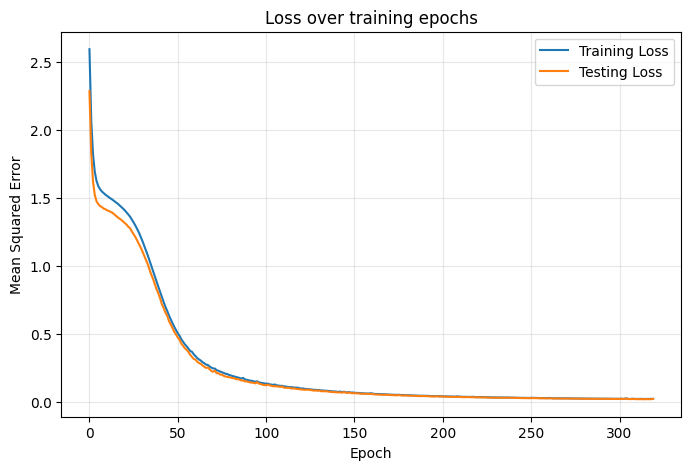

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Testing Loss")
plt.title("Loss over training epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Final Test MSE: 0.024346
Final Test MAE: 0.122421


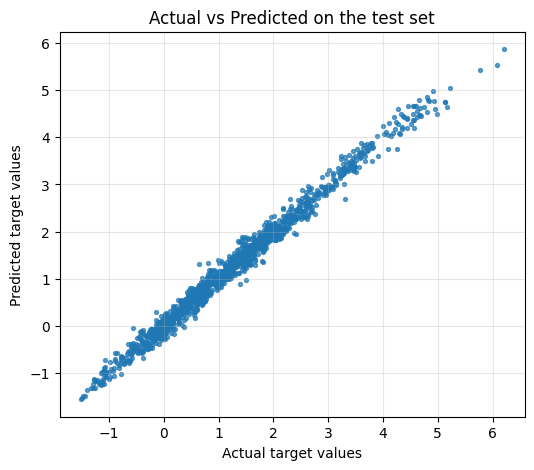

In [11]:
with torch.no_grad():
    final_test_predictions, _ = forward_pass(X_test)

final_mse = mean_squared_error(final_test_predictions, y_test).item()
final_mae = mean_absolute_error(final_test_predictions, y_test).item()

print("Final Test MSE:", round(final_mse, 6))
print("Final Test MAE:", round(final_mae, 6))

plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze().numpy(), final_test_predictions.squeeze().numpy(), s=8, alpha=0.7)
plt.xlabel("Actual target values")
plt.ylabel("Predicted target values")
plt.title("Actual vs Predicted on the test set")
plt.grid(alpha=0.3)
plt.show()

### Final Observation
In this notebook, I built a 3-layer neural network in PyTorch completely from scratch without using built-in layer modules like `nn.Linear`. I manually handled the forward pass, loss calculation, and backpropagation, and the model was able to learn the nonlinear pattern in the regression data as the loss kept decreasing during training.